# Comparison: MDMP vs MDMR (HC and NOTEARS)

This notebook compares structure learning results across methods and implementations:
- **MDMP-HC**: MDMP (Python) with hill-climbing
- **MDMP-NOTEARS**: MDMP (Python) with NOTEARS
- **MDMR-HC**: MDMR (R) with hill-climbing

on two simulated DAG structures (3-var and 5-var).

## Metrics Compared:
- Connection accuracy
- Sensitivity (true positive rate)
- Specificity (true negative rate)
- Positive Predictive Value (PPV)
- Negative Predictive Value (NPV)
- Directional accuracy
- Discount factors
- Computation time
- Number of edges

## Visualizations:
- Side-by-side comparison tables
- Bar charts comparing metrics
- Heatmaps of adjacency matrices (true, MDMP-HC, MDMP-NOTEARS, MDMR-HC)

In [16]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

## Load Results

Load results from MDMP (HC), MDMP (NOTEARS), and MDMR (HC) notebooks.

In [11]:
# Define data directory
data_dir = "./data/"

# Load results
results_mdmp = pd.read_csv(os.path.join(data_dir, "mdmp_results.csv"))
results_notears = pd.read_csv(os.path.join(data_dir, "notears_results.csv"))
results_mdmr = pd.read_csv(os.path.join(data_dir, "mdmr_results.csv"))

# Load adjacency matrices
true_adj_3var = pd.read_csv(
    os.path.join(data_dir, "dag_3var_true_adjacency.csv"),
    index_col=0
).values.astype(int)

mdmp_adj_3var = pd.read_csv(
    os.path.join(data_dir, "mdmp_adjacency_3var.csv"),
    index_col=0
).values.astype(int)

notears_adj_3var = pd.read_csv(
    os.path.join(data_dir, "notears_adjacency_3var.csv"),
    index_col=0
).values.astype(int)

mdmr_adj_3var = pd.read_csv(
    os.path.join(data_dir, "mdmr_adjacency_3var.csv"),
    index_col=0
).values.astype(int)

true_adj_5var = pd.read_csv(
    os.path.join(data_dir, "dag_5var_true_adjacency.csv"),
    index_col=0
).values.astype(int)

mdmp_adj_5var = pd.read_csv(
    os.path.join(data_dir, "mdmp_adjacency_5var.csv"),
    index_col=0
).values.astype(int)

notears_adj_5var = pd.read_csv(
    os.path.join(data_dir, "notears_adjacency_5var.csv"),
    index_col=0
).values.astype(int)

mdmr_adj_5var = pd.read_csv(
    os.path.join(data_dir, "mdmr_adjacency_5var.csv"),
    index_col=0
).values.astype(int)

print("Results loaded successfully!")
print(f"\nMDMP (HC) results shape: {results_mdmp.shape}")
print(f"MDMP (NOTEARS) results shape: {results_notears.shape}")
print(f"MDMR (HC) results shape: {results_mdmr.shape}")

Results loaded successfully!

MDMP (HC) results shape: (18, 4)
MDMP (NOTEARS) results shape: (18, 4)
MDMR (HC) results shape: (18, 4)


## Comparison Tables

Create side-by-side comparison tables for all metrics.

In [12]:
# Create comparison tables
def create_comparison_table(results_mdmp, results_notears, results_mdmr, dag):
    """Create a comparison table for a specific DAG."""
    mdmp_subset = results_mdmp[results_mdmp['dag'] == dag].copy()
    notears_subset = results_notears[results_notears['dag'] == dag].copy()
    mdmr_subset = results_mdmr[results_mdmr['dag'] == dag].copy()

    comparison = pd.DataFrame({
        'metric': mdmp_subset['metric'].values,
        'MDMP-HC': mdmp_subset['value'].values,
        'MDMP-NOTEARS': notears_subset['value'].values,
        'MDMR-HC': mdmr_subset['value'].values
    })
    return comparison

# 3-variable DAG comparison
comp_3var = create_comparison_table(results_mdmp, results_notears, results_mdmr, '3var')
print("3-Variable DAG Comparison:")
print(comp_3var.to_string(index=False))

# 5-variable DAG comparison
comp_5var = create_comparison_table(results_mdmp, results_notears, results_mdmr, '5var')
print("\n\n5-Variable DAG Comparison:")
print(comp_5var.to_string(index=False))

3-Variable DAG Comparison:
              metric  MDMP-HC  MDMP-NOTEARS  MDMR-HC
            accuracy 1.000000      1.000000 1.000000
         sensitivity 1.000000      1.000000 1.000000
         specificity 1.000000      1.000000 1.000000
                 ppv 1.000000      1.000000 1.000000
                 npv 1.000000      1.000000 1.000000
directional_accuracy 1.000000      1.000000 1.000000
 num_edges_estimated 2.000000      2.000000 2.000000
      num_edges_true 2.000000      2.000000 2.000000
    computation_time 8.351367      1.213963 1.978934


5-Variable DAG Comparison:
              metric   MDMP-HC  MDMP-NOTEARS  MDMR-HC
            accuracy  0.900000      0.900000 0.900000
         sensitivity  1.000000      0.800000 1.000000
         specificity  0.800000      1.000000 0.800000
                 ppv  0.833333      1.000000 0.833333
                 npv  1.000000      0.833333 1.000000
directional_accuracy  1.000000      0.800000 1.000000
 num_edges_estimated  6.000000      

## Visualizations

### Bar Charts: Metrics Comparison

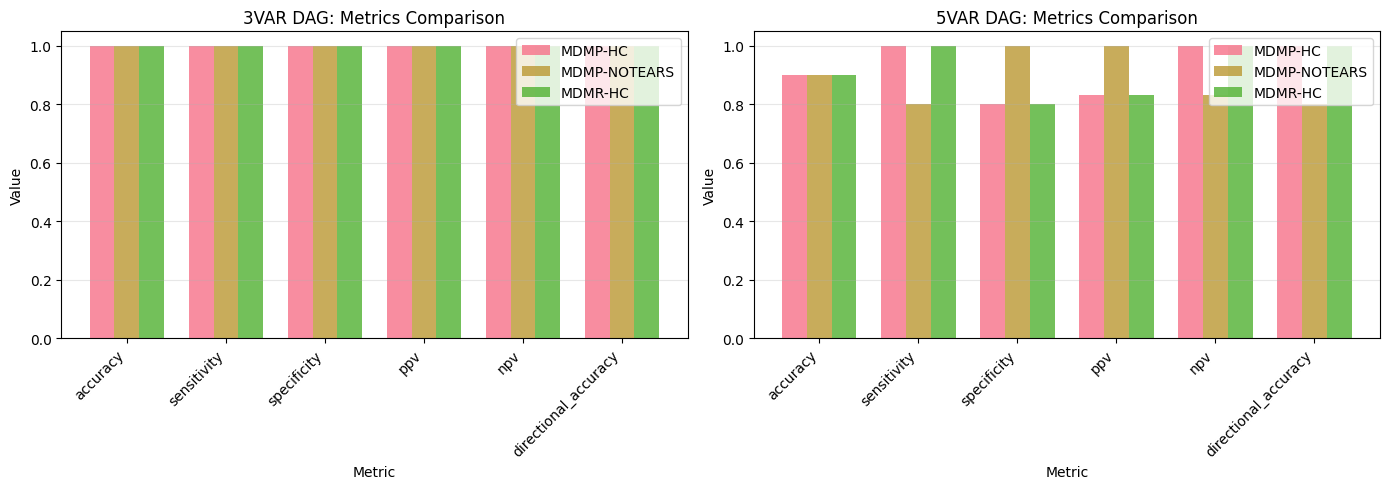

In [ ]:
# Metrics to plot (excluding edge counts and time)
metrics_to_plot = ['accuracy', 'sensitivity', 'specificity', 'ppv', 'npv', 'directional_accuracy']

# Create comparison plots for both DAGs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, dag in enumerate(['3var', '5var']):
    comp_df = create_comparison_table(results_mdmp, results_notears, results_mdmr, dag)
    comp_metrics = comp_df[comp_df['metric'].isin(metrics_to_plot)]

    x = np.arange(len(comp_metrics))
    width = 0.25

    axes[idx].bar(x - width, comp_metrics['MDMP-HC'], width, label='MDMP-HC', alpha=0.8)
    axes[idx].bar(x, comp_metrics['MDMP-NOTEARS'], width, label='MDMP-NOTEARS', alpha=0.8)
    axes[idx].bar(x + width, comp_metrics['MDMR-HC'], width, label='MDMR-HC', alpha=0.8)

    axes[idx].set_xlabel('Metric')
    axes[idx].set_ylabel('Value')
    axes[idx].set_title(f'{dag.upper()} DAG: Metrics Comparison')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(comp_metrics['metric'], rotation=45, ha='right')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Heatmaps: Adjacency Matrices Comparison

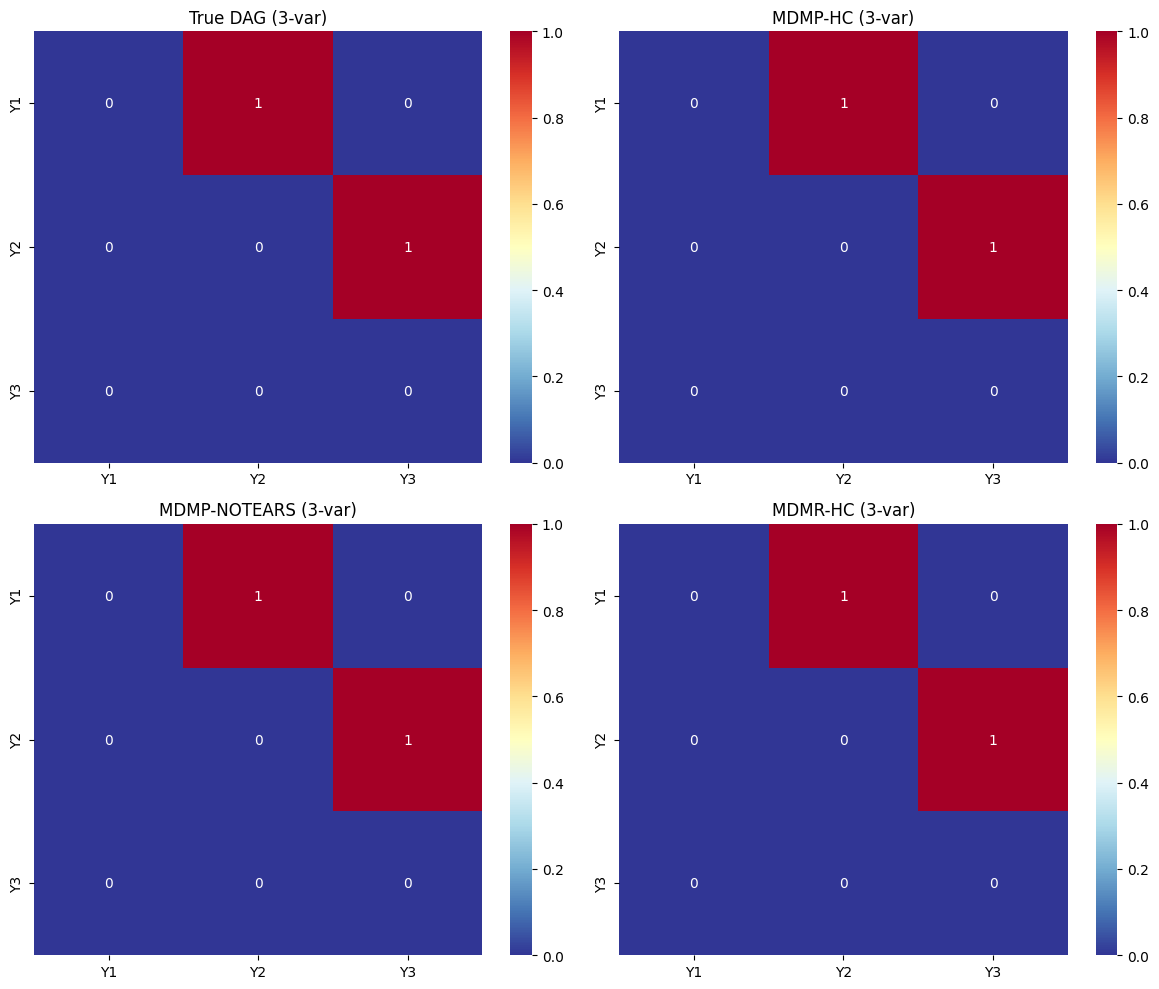

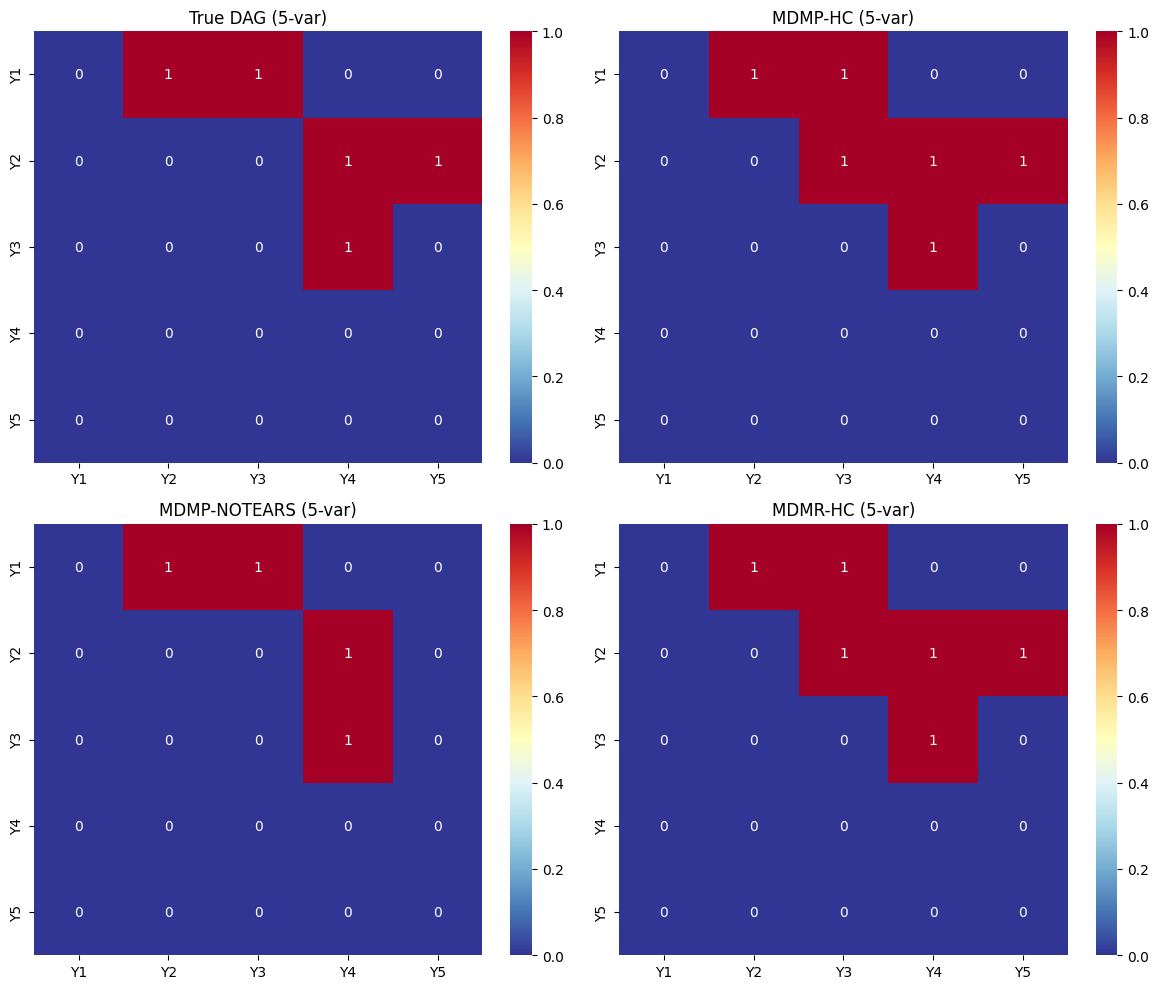

In [18]:
# Helper function to plot adjacency matrix heatmap
def plot_adj_heatmap(adj_mat, title, ax, node_names=None):
    """Plot adjacency matrix as heatmap."""
    if node_names is None:
        node_names = [f"Y{i+1}" for i in range(adj_mat.shape[0])]

    sns.heatmap(adj_mat, annot=True, fmt='d', cmap='RdYlBu_r',
                xticklabels=node_names, yticklabels=node_names,
                cbar=True, ax=ax, vmin=0, vmax=1)
    ax.set_title(title)

# 3-variable DAG adjacency matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
node_names_3var = ['Y1', 'Y2', 'Y3']

plot_adj_heatmap(true_adj_3var, 'True DAG (3-var)', axes[0, 0], node_names_3var)
plot_adj_heatmap(mdmp_adj_3var, 'MDMP-HC (3-var)', axes[0, 1], node_names_3var)
plot_adj_heatmap(notears_adj_3var, 'MDMP-NOTEARS (3-var)', axes[1, 0], node_names_3var)
plot_adj_heatmap(mdmr_adj_3var, 'MDMR-HC (3-var)', axes[1, 1], node_names_3var)

plt.tight_layout()
plt.show()

# 5-variable DAG adjacency matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
node_names_5var = ['Y1', 'Y2', 'Y3', 'Y4', 'Y5']

plot_adj_heatmap(true_adj_5var, 'True DAG (5-var)', axes[0, 0], node_names_5var)
plot_adj_heatmap(mdmp_adj_5var, 'MDMP-HC (5-var)', axes[0, 1], node_names_5var)
plot_adj_heatmap(notears_adj_5var, 'MDMP-NOTEARS (5-var)', axes[1, 0], node_names_5var)
plot_adj_heatmap(mdmr_adj_5var, 'MDMR-HC (5-var)', axes[1, 1], node_names_5var)

plt.tight_layout()
plt.show()

### Computation Time Comparison

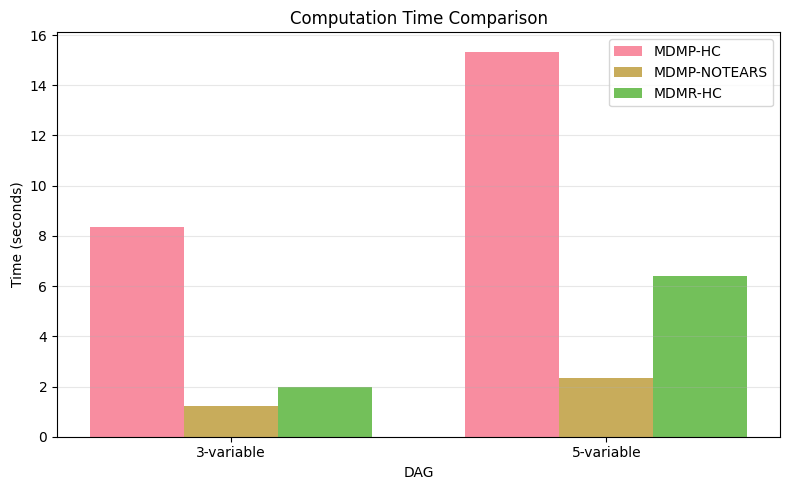

In [19]:
# Extract computation times
time_mdmp_3var = results_mdmp[(results_mdmp['dag'] == '3var') &
                               (results_mdmp['metric'] == 'computation_time')]['value'].values[0]
time_notears_3var = results_notears[(results_notears['dag'] == '3var') &
                                    (results_notears['metric'] == 'computation_time')]['value'].values[0]
time_mdmr_3var = results_mdmr[(results_mdmr['dag'] == '3var') &
                               (results_mdmr['metric'] == 'computation_time')]['value'].values[0]
time_mdmp_5var = results_mdmp[(results_mdmp['dag'] == '5var') &
                               (results_mdmp['metric'] == 'computation_time')]['value'].values[0]
time_notears_5var = results_notears[(results_notears['dag'] == '5var') &
                                    (results_notears['metric'] == 'computation_time')]['value'].values[0]
time_mdmr_5var = results_mdmr[(results_mdmr['dag'] == '5var') &
                               (results_mdmr['metric'] == 'computation_time')]['value'].values[0]

# Plot computation times
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.25

mdmp_times = [time_mdmp_3var, time_mdmp_5var]
notears_times = [time_notears_3var, time_notears_5var]
mdmr_times = [time_mdmr_3var, time_mdmr_5var]

ax.bar(x - width, mdmp_times, width, label='MDMP-HC', alpha=0.8)
ax.bar(x, notears_times, width, label='MDMP-NOTEARS', alpha=0.8)
ax.bar(x + width, mdmr_times, width, label='MDMR-HC', alpha=0.8)

ax.set_xlabel('DAG')
ax.set_ylabel('Time (seconds)')
ax.set_title('Computation Time Comparison')
ax.set_xticks(x)
ax.set_xticklabels(['3-variable', '5-variable'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()